### CNNs applied to time series

In [8]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 14

import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten #, Reshape
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D

%run plot.py

### Read data

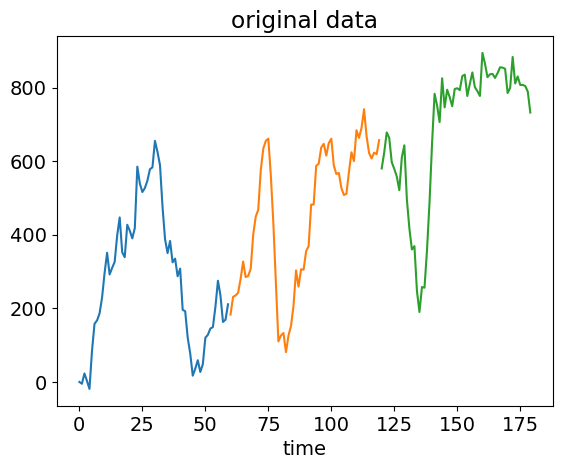

data:  10000


In [10]:
str0 = 'ts_L60_Z12_A500_DX50_bias5_N10000.dat'
fnamex='DATA/x_'+str0
fnamey='DATA/y_'+str0

x = np.loadtxt(fnamex, delimiter=" ",dtype=float)
# number of samples, number of features
N,L = len(x), len(x[0])

Show_data(x,L,"original data")

categ = np.loadtxt(fnamey, dtype=int)
n_class = 3    # y.argmax() - y.argmin() +1
print('data: ',N)

y = np.zeros((N,n_class))
for i in range(N):
    y[i][categ[i]] = 1. # y contains one-hot encoding

In [15]:
x.shape

(10000, 60)

### Split train-validation and rescale

In [25]:
x_train.shape
#x_val.shape

(8000, 60, 1)

## Convolutional NN

In [9]:
# ...LESSON ...
# reproducibility
np.random.seed(12345)
import tensorflow.random as tf_r
tf_r.set_seed(12345)

## from keras import regularizers, initializers

reg = tf.keras.regularizers.l2(0.2) ## raised to 0.2 the regularization strenghts
#reg = regularizers.l1(0.1)
ini = tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05, 
                                        seed=None)
NCONV = 1 #swtich between 1 and 2 CNNs
NF = 5 #number of filters

# challenge: at most 600 tunable parameters
model = Sequential()
# 
if NCONV==1:
    # -----2-----
    model.add(Conv1D(filters=NF, kernel_size=11, 
                     kernel_initializer=ini, 
                     kernel_regularizer=reg,
                     activation='relu', 
                     input_shape=input_shape))
    #model.add(MaxPooling1D(3))
    model.add(AveragePooling1D(5))
    model.add(Conv1D(filters=5, kernel_size=7, 
                     activation='relu'))
    model.add(Flatten())
    model.add(Dense(12, activation='relu'))
    model.add(Dropout(0.2))
# 
if NCONV==2:
    # -----1-----
    model.add(Conv1D(filters=NF, kernel_size=11, 
                     kernel_initializer=ini, 
                     kernel_regularizer=reg, ######## TRY WITHOUT !
                     activation='relu', input_shape=input_shape))
    #model.add(MaxPooling1D(3))
    model.add(AveragePooling1D(5))
    model.add(Flatten())
    model.add(Dense(9, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(6, activation='relu'))
    model.add(Dropout(0.2))
    #model.add(Dense(10, activation='relu'))
    #model.add(Dropout(0.3))
model.add(Dense(n_class, activation='softmax')) # softmax !

print('----- Model',NCONV,'-----')
print(model.summary())

# optimizers
# .SGD(lr=0.01, momentum=0.9, nesterov=True) # decay=1e-6,
# .RMSprop()
# .Nadam()
opt = tf.keras.optimizers.Adam()

# compile the model
# categorical_crossentropy, 3 output nodes
model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=opt,metrics=['accuracy'])

C:\Users\melis\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


----- Model 1 -----


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 50, 5)               │              60 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling1d (AveragePooling1D) │ (None, 10, 5)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 4, 5)                │             180 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 20)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 12)                  │             252 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 12)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │              39 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 531 (2.07 KB)

 Trainable params: 531 (2.07 KB)

 Non-trainable params: 0 (0.00 B)

None


In [10]:
model.layers

[<Conv1D name=conv1d, built=True>,
 <AveragePooling1D name=average_pooling1d, built=True>,
 <Conv1D name=conv1d_1, built=True>,
 <Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dropout name=dropout, built=True>,
 <Dense name=dense_1, built=True>]

(11, 1, 5)
(5, 1, 11)


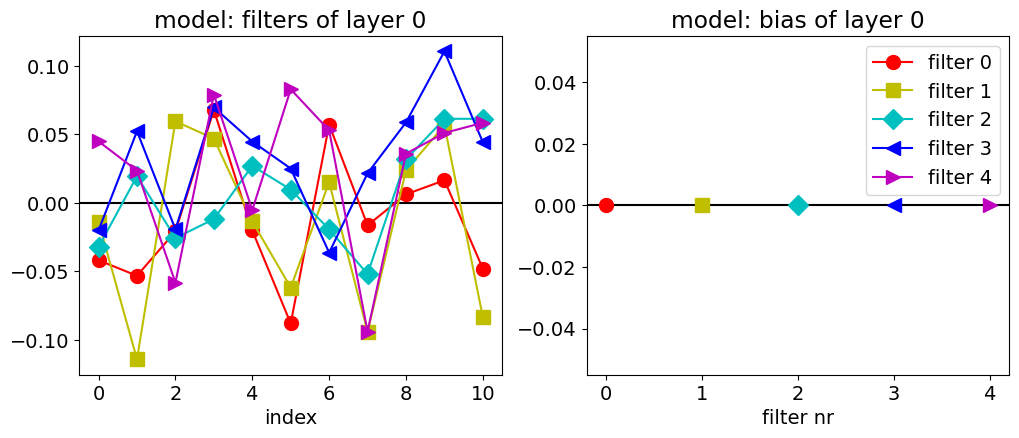

(7, 5, 5)
(5, 5, 7)


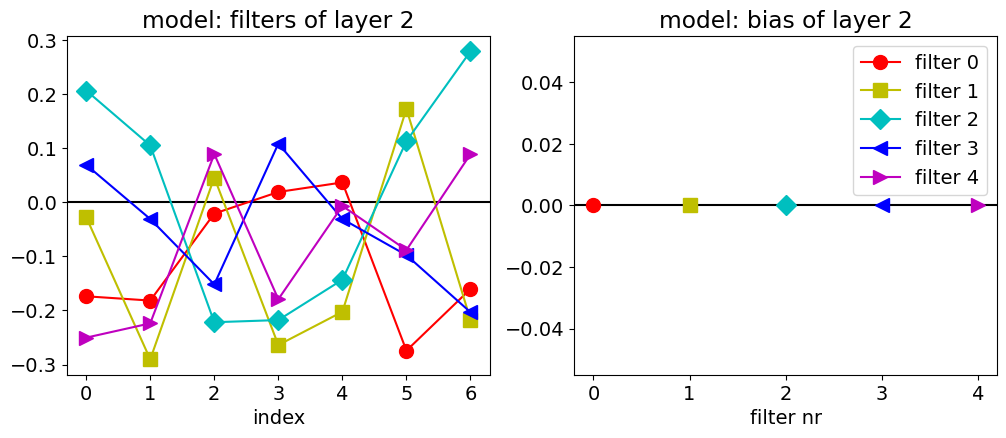

In [11]:
def Show_weights(model,l=0,label="model"):
    c=['r','y','c','b','m']
    m=['o','s','D','<','>']
    ms=10
    
    w = model.layers[l].get_weights()[0] # weights
    print(w.shape)
    wT=w.T
    print(wT.shape)
    M=len(wT)
    b = model.layers[l].get_weights()[1] # bias
    
    fig,AX=plt.subplots(1,2,figsize=(12,4.4))
    ax=AX[0]
    ax.axhline(0, c="k")
    ax.plot((0,))
    for i in range(M):
        ax.plot(wT[i][0],"-",c=c[i],marker=m[i],label=str(i),markersize=ms)
    ax.set_title(label+': filters of layer '+str(l))
    ax.set_xlabel('index')
    ax=AX[1]
    ax.axhline(0, c="k")
    for i in range(M):
        ax.plot((i),(b[i]),c=c[i],marker=m[i],label="filter "+str(i),markersize=ms)
    ax.set_title(label+': bias of layer '+str(l))
    ax.set_xlabel('filter nr')
    ax.set_xticks(np.arange(5))
    ax.legend()
    plt.show()
    
Show_weights(model,0)
Show_weights(model,2)

In [12]:
# ...LESSON ...
# Hyper-parameters
# with small minibatch it does not converge!! 
BATCH_SIZE = 200
EPOCHS = 150

print('----- Model ',NCONV,'-----\nFITTING....')
fit = model.fit(x_train,y_train,batch_size=BATCH_SIZE,
                epochs=EPOCHS,
                validation_data=(x_val, y_val),
                verbose=2, shuffle=True) 

----- Model  1 -----
FITTING....
Epoch 1/150
40/40 - 3s - 67ms/step - accuracy: 0.3479 - loss: 1.1098 - val_accuracy: 0.3920 - val_loss: 1.0940
Epoch 2/150
40/40 - 0s - 9ms/step - accuracy: 0.4223 - loss: 1.0753 - val_accuracy: 0.4785 - val_loss: 1.0561
Epoch 3/150
40/40 - 0s - 9ms/step - accuracy: 0.5141 - loss: 1.0318 - val_accuracy: 0.5865 - val_loss: 0.9979
Epoch 4/150
40/40 - 0s - 10ms/step - accuracy: 0.5959 - loss: 0.9669 - val_accuracy: 0.6645 - val_loss: 0.9266
Epoch 5/150
40/40 - 1s - 17ms/step - accuracy: 0.6607 - loss: 0.9017 - val_accuracy: 0.7340 - val_loss: 0.8534
Epoch 6/150
40/40 - 1s - 16ms/step - accuracy: 0.7200 - loss: 0.8317 - val_accuracy: 0.7995 - val_loss: 0.7771
Epoch 7/150
40/40 - 0s - 9ms/step - accuracy: 0.7725 - loss: 0.7571 - val_accuracy: 0.8385 - val_loss: 0.6913
Epoch 8/150
40/40 - 0s - 9ms/step - accuracy: 0.8087 - loss: 0.6805 - val_accuracy: 0.8645 - val_loss: 0.6059
Epoch 9/150
40/40 - 0s - 9ms/step - accuracy: 0.8407 - loss: 0.6089 - val_accuracy:

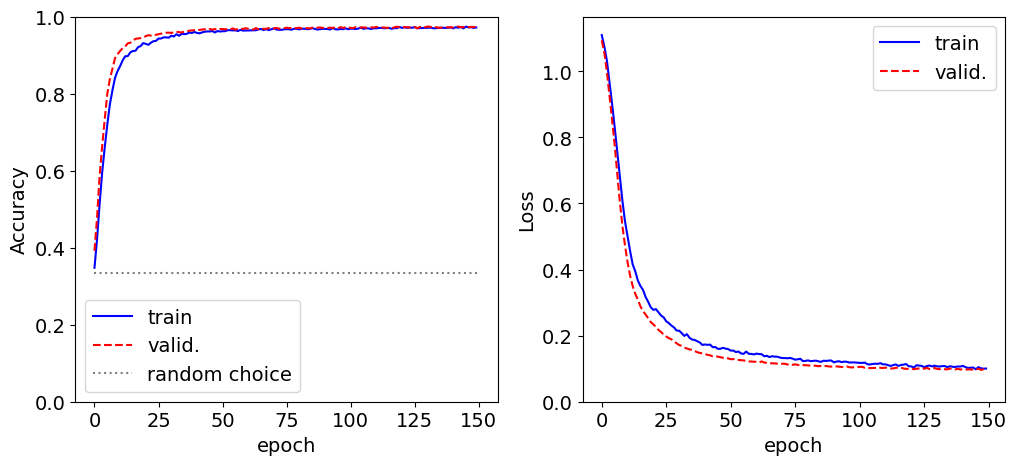

(11, 1, 5)
(5, 1, 11)


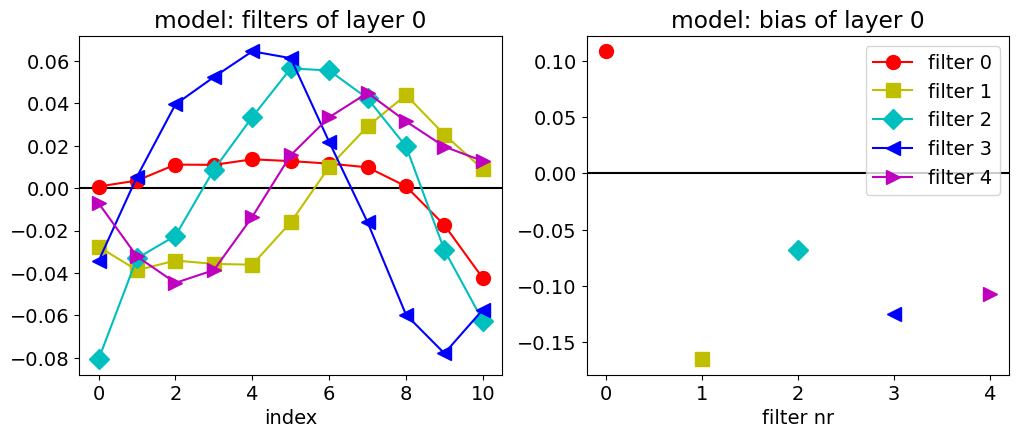

(7, 5, 5)
(5, 5, 7)


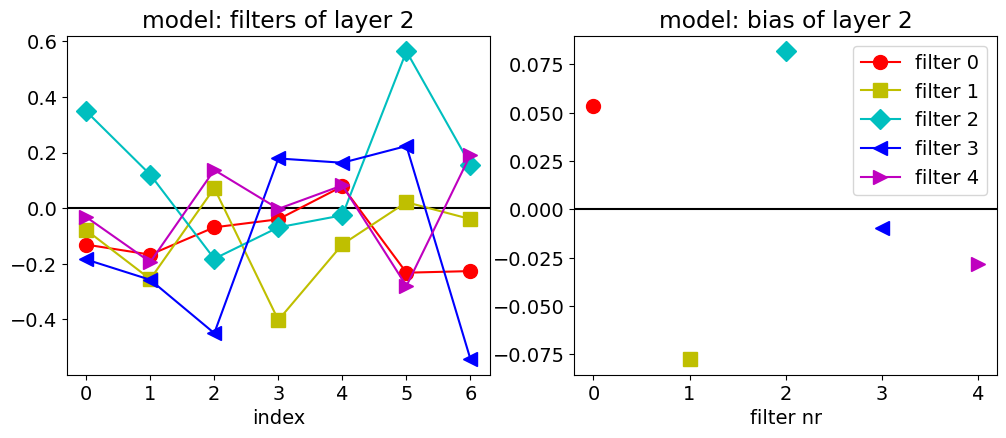

In [13]:
def Show_history(fit):
    fig,AX=plt.subplots(1,2,figsize=(12,5.))
    ax=AX[0] 
    ax.plot(fit.history['accuracy'],"b",label="train")
    ax.plot(fit.history['val_accuracy'],"r--",label="valid.")
    ax.plot((0,EPOCHS),(1/3,1/3),":",c="gray",label="random choice")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Accuracy")
    ax.set_ylim([0, 1])
    ax.legend()
    ax=AX[1]
    ax.plot(fit.history['loss'],"b",label="train")
    ax.plot(fit.history['val_loss'],"r--",label="valid.")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Loss")
    ax.set_ylim([0, 1.05*np.max(fit.history['loss'])])
    ax.legend()
    plt.show()
Show_history(fit)
Show_weights(model,0)
Show_weights(model,2)

In [14]:
# ...LESSON ...
reg2 = tf.keras.regularizers.l1(0.5)
model2 = keras.models.clone_model(model)
model2.layers[0].kernel_regularizer = reg2
model2.layers[2].kernel_regularizer = reg2
opt2 = tf.keras.optimizers.Adam()   # NEW optimizer instance
model2.compile(loss=keras.losses.categorical_crossentropy,optimizer=opt2,metrics=['accuracy'])

BATCH_SIZE2 = 200
EPOCHS2 = 150

fit2 = model2.fit(x_train,y_train,batch_size=BATCH_SIZE2,epochs=EPOCHS2,
                validation_data=(x_val, y_val), verbose=2, shuffle=True) 

Epoch 1/150
40/40 - 2s - 53ms/step - accuracy: 0.4125 - loss: 1.1042 - val_accuracy: 0.4515 - val_loss: 1.0811
Epoch 2/150
40/40 - 0s - 10ms/step - accuracy: 0.4944 - loss: 1.0592 - val_accuracy: 0.5580 - val_loss: 1.0262
Epoch 3/150
40/40 - 0s - 8ms/step - accuracy: 0.5644 - loss: 0.9988 - val_accuracy: 0.6055 - val_loss: 0.9521
Epoch 4/150
40/40 - 0s - 9ms/step - accuracy: 0.6104 - loss: 0.9299 - val_accuracy: 0.6440 - val_loss: 0.8771
Epoch 5/150
40/40 - 0s - 8ms/step - accuracy: 0.6419 - loss: 0.8628 - val_accuracy: 0.6750 - val_loss: 0.8104
Epoch 6/150
40/40 - 0s - 9ms/step - accuracy: 0.6628 - loss: 0.8069 - val_accuracy: 0.7080 - val_loss: 0.7525
Epoch 7/150
40/40 - 0s - 9ms/step - accuracy: 0.6900 - loss: 0.7579 - val_accuracy: 0.7300 - val_loss: 0.7015
Epoch 8/150
40/40 - 0s - 10ms/step - accuracy: 0.7076 - loss: 0.7157 - val_accuracy: 0.7520 - val_loss: 0.6560
Epoch 9/150
40/40 - 0s - 9ms/step - accuracy: 0.7374 - loss: 0.6652 - val_accuracy: 0.7950 - val_loss: 0.5982
Epoch 1

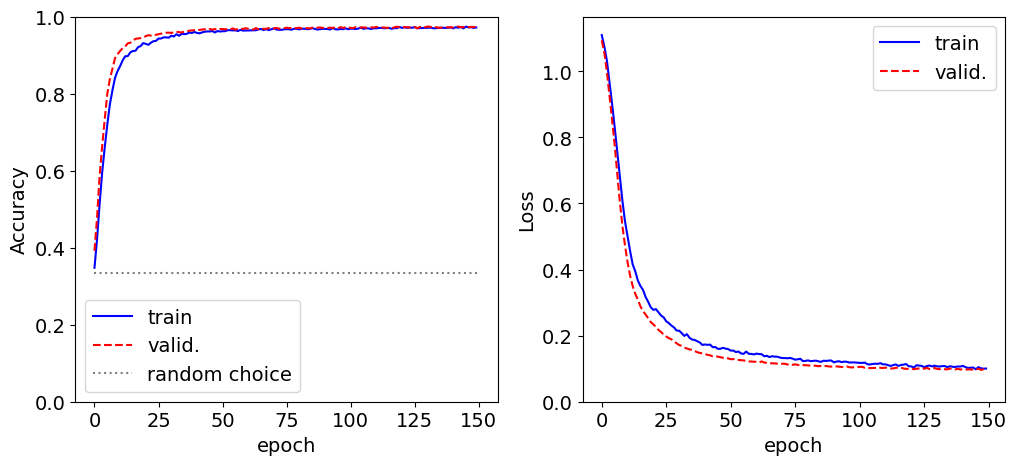

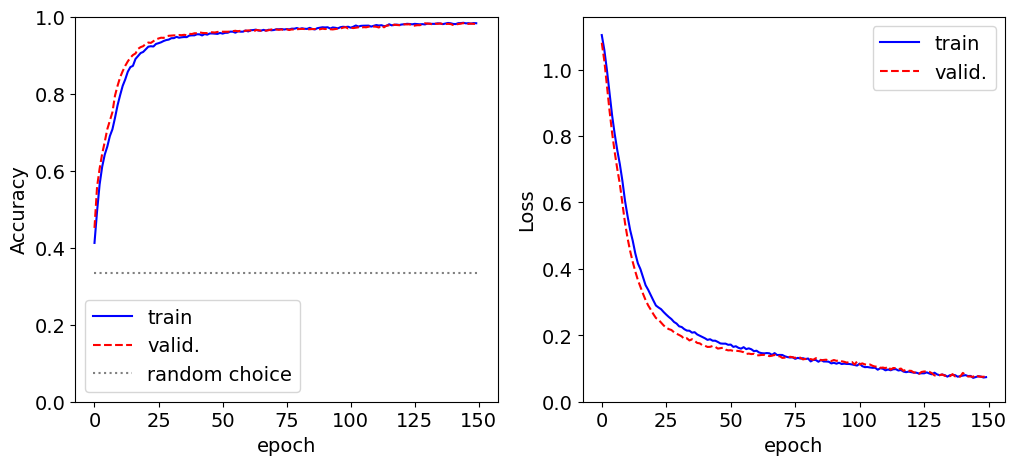

(11, 1, 5)
(5, 1, 11)


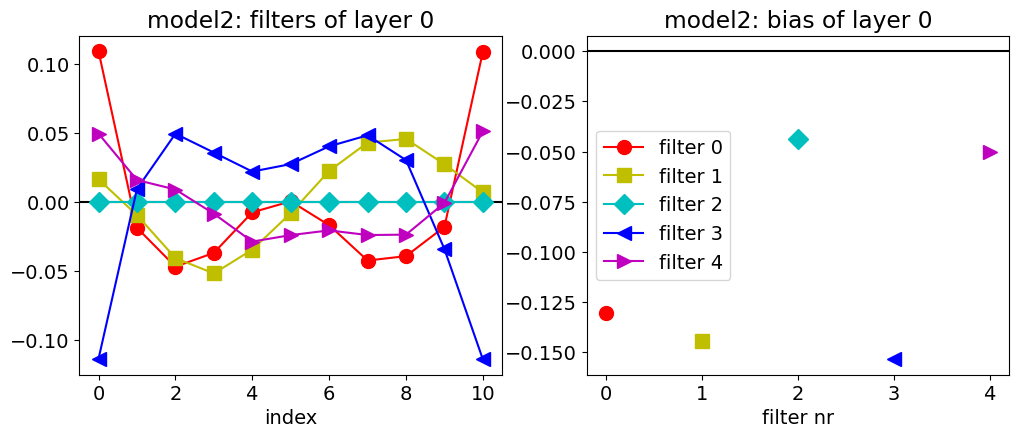

(7, 5, 5)
(5, 5, 7)


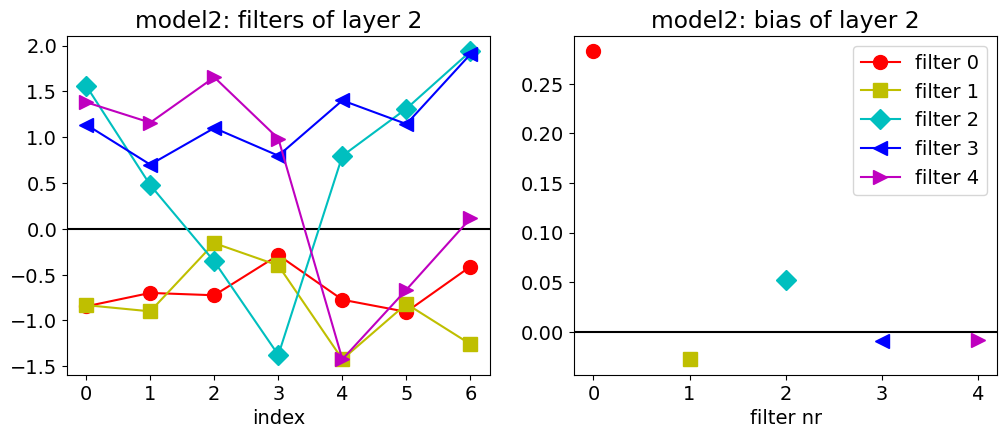

In [15]:
Show_history(fit)
Show_history(fit2)
Show_weights(model2,0,label="model2")
Show_weights(model2,2,label="model2")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


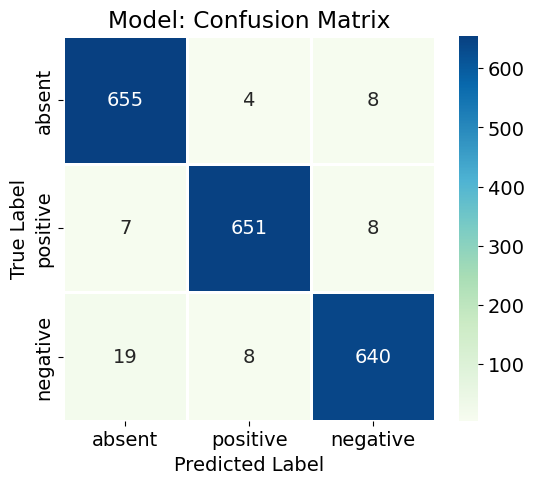

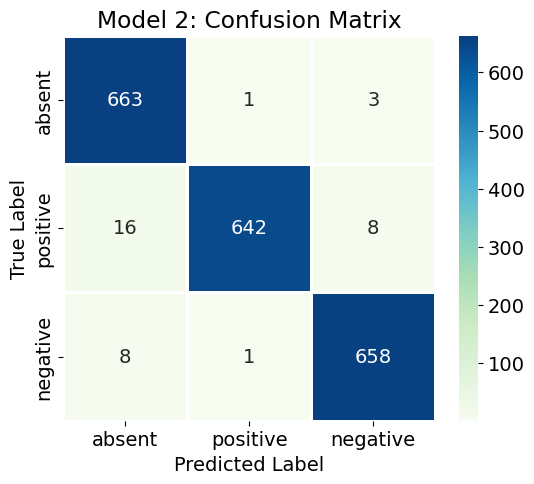

In [16]:
# confusion table: compare true labels with predicted ones
import pandas as pd
from scipy import stats

import seaborn 
from sklearn import metrics

from sklearn.metrics import classification_report
from sklearn import preprocessing

LABELS = ["absent","positive","negative"] # from labels y 
cmap="GnBu"

def show_confusion_matrix(validations, predictions, label="Model"):

    matrix = metrics.confusion_matrix(validations, predictions)
    plt.figure(figsize=(6, 5))
    seaborn.heatmap(matrix,
                xticklabels=LABELS,
                yticklabels=LABELS,
                annot=True,
                fmt='d',
                linecolor='white',
                linewidths=1,
                cmap=cmap)
    plt.title(label+': Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

y_pred_val = model.predict(x_val)
y_pred_val2 = model2.predict(x_val)
# Take the class with the highest probability from the val predictions
max_y_pred_val = np.argmax(y_pred_val, axis=1)
max_y_val = np.argmax(y_val, axis=1)
max_y_pred_val2 = np.argmax(y_pred_val2, axis=1)

show_confusion_matrix(max_y_val, max_y_pred_val)
show_confusion_matrix(max_y_val, max_y_pred_val2, label="Model 2")

#print(classification_report(max_y_val, max_y_pred_val))

# Exercise - studies


In [28]:
#first generate dataset thats (L,2) - OR try to use the same as provided

In [42]:
def pattern(i,z,a):
    return int(a*np.sin((np.pi*i)/z))

In [ ]:
#Reutilizing the functions from generate data - STUDY + CLEAN
jump = lambda drift, stdev: int(np.random.normal(drift,stdev))

def pattern(i,z,a):
    return int(a*np.sin((np.pi*i)/z))

np.random.seed(12345)

Z = 12
A = 500
N = 10000
L = 60
DX = 50 
bias = 5  

# --- MUDANÇA 1: Inicialização com 2 colunas (canais) ---
# Formato: (Número de amostras, Comprimento, 2 séries)
x = np.zeros((N, L, 2))
y = np.zeros(N, dtype=int)

for i in range(N):
    # --- MUDANÇA 2: Random Walk para ambas as séries ---
    for s in range(2): # Loop pelas duas séries (0 e 1)
        if i > 0:
            # Começa onde a amostra anterior terminou naquela série específica
            x[i, 0, s] = x[i-1, -1, s] + jump(bias, DX)
        
        for j in range(1, L):
            x[i, j, s] = x[i, j-1, s] + jump(bias, DX)
    
    # --- MUDANÇA 3: Inserção do Padrão em Paralelo/Sequência ---
    y[i] = i % 3
    
    if y[i] > 0:
        # Definimos um ponto de início que caiba os dois padrões (um após o outro)
        # Z é o tamanho do padrão, então precisamos de pelo menos 2*Z de espaço
        j0 = np.random.randint(0, L - 2*Z - 1) 
        sign = 3 - 2*y[i]
        
        # Padrão na Série 1 (coluna 0)
        for j in range(Z):
            x[i, j0 + j, 0] += sign * pattern(j, Z, A)
            
        # Padrão na Série 2 (coluna 1) - começando logo após o primeiro terminar
        j1 = j0 + Z 
        for j in range(Z):
            x[i, j1 + j, 1] += sign * pattern(j, Z, A)

# Exemplo de saída da primeira amostra (mostrando os dois canais no primeiro passo)
print(f"Shape do dataset: {x.shape}")
print(f"Primeiro passo da Amostra 0 (Série 1, Série 2): {x[0, 0, :]}")

In [48]:
# split into training and validation sets - STUDY
perc_train=0.8
N_train = int(perc_train*N)
x_train = x[:N_train]
print(x_train.shape)
y_train = y[:N_train]
x_val = x[N_train:]
y_val = y[N_train:]
N_val = len(x_val)
print('N_train=',N_train,'  N_val=',N_val,'  L=',L,'  n_class=',n_class)

 
#remove average value of each sample from its values
xm_train = x_train.mean(axis=1)
std_train = x_train.std(axis=1)
xm_val = x_val.mean(axis=1)
std_val = x_val.std(axis=1)
print('std_train average and mean:',max(std_train), min(std_train), std_train.mean(axis=0))
print('std_val average and mean:',max(std_val), min(std_val), std_val.mean(axis=0))

# rescale with variance on the training set
for i in range(N_train):
    #x_train[i] = (x_train[i]-xm_train[i])/ std_train[i] #not good, std_train is very variable across samples
     #x_train[i] = (x_train[i]-xm_train[i])/ 400 #crude rescaling, variance should be used
     x_train[i] = (x_train[i]-xm_train[i])/ std_train.mean(axis=0)
for i in range(N_val):
    #x_val[i] = (x_val[i]-xm_val[i])/ std_val[i]
    #x_val[i] = (x_val[i]-xm_val[i])/ 400
    x_val[i] = (x_val[i]-xm_val[i])/ std_val.mean(axis=0)
#

    
Show_data(x_train,L,"rescaled train data")
Show_data(x_val,L,"rescaled validation data")

#x_train=x_train.astype("float32")
#y_train=y_train.astype("float32")
#x_val=x_val.astype("float32")
#y_val=y_val.astype("float32")


#x_train = x_train.reshape(x_train.shape[0], L, 2)
#x_val =  x_val.reshape(x_val.shape[0], L, 2)
#input_shape = (L, 2) # number of features, number of channels (1 for 1D data)

###data is normalized - by the mean : fixed number over the whole dataset

(8000, 60, 2)
N_train= 8000   N_val= 2000   L= 60   n_class= 3


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()